<a href="https://colab.research.google.com/github/y7chinmay/Wine-Quality-Prediction/blob/main/Wine_Quality_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn import metrics
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression

import warnings
warnings.filterwarnings('ignore')



In [3]:
df = pd.read_csv('winequalityN.csv')
print(df.head())

    type  fixed acidity  volatile acidity  citric acid  residual sugar  \
0  white            7.0              0.27         0.36            20.7   
1  white            6.3              0.30         0.34             1.6   
2  white            8.1              0.28         0.40             6.9   
3  white            7.2              0.23         0.32             8.5   
4  white            7.2              0.23         0.32             8.5   

   chlorides  free sulfur dioxide  total sulfur dioxide  density    pH  \
0      0.045                 45.0                 170.0   1.0010  3.00   
1      0.049                 14.0                 132.0   0.9940  3.30   
2      0.050                 30.0                  97.0   0.9951  3.26   
3      0.058                 47.0                 186.0   0.9956  3.19   
4      0.058                 47.0                 186.0   0.9956  3.19   

   sulphates  alcohol  quality  
0       0.45      8.8        6  
1       0.49      9.5        6  
2       0.4

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   type                  6497 non-null   object 
 1   fixed acidity         6487 non-null   float64
 2   volatile acidity      6489 non-null   float64
 3   citric acid           6494 non-null   float64
 4   residual sugar        6495 non-null   float64
 5   chlorides             6495 non-null   float64
 6   free sulfur dioxide   6497 non-null   float64
 7   total sulfur dioxide  6497 non-null   float64
 8   density               6497 non-null   float64
 9   pH                    6488 non-null   float64
 10  sulphates             6493 non-null   float64
 11  alcohol               6497 non-null   float64
 12  quality               6497 non-null   int64  
dtypes: float64(11), int64(1), object(1)
memory usage: 660.0+ KB


In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
fixed acidity,6487.0,7.216579,1.296750,3.80000,6.40000,7.00000,7.70000,15.90000
volatile acidity,6489.0,0.339691,0.164649,0.08000,0.23000,0.29000,0.40000,1.58000
citric acid,6494.0,0.318722,0.145265,0.00000,0.25000,0.31000,0.39000,1.66000
residual sugar,6495.0,5.444326,4.758125,0.60000,1.80000,3.00000,8.10000,65.80000
chlorides,6495.0,0.056042,0.035036,0.00900,0.03800,0.04700,0.06500,0.61100
free sulfur dioxide,6497.0,30.525319,17.749400,1.00000,17.00000,29.00000,41.00000,289.00000
total sulfur dioxide,6497.0,115.744574,56.521855,6.00000,77.00000,118.00000,156.00000,440.00000
density,6497.0,0.994697,0.002999,0.98711,0.99234,0.99489,0.99699,1.03898
pH,6488.0,3.218395,0.160748,2.72000,3.11000,3.21000,3.32000,4.01000
sulphates,6493.0,0.531215,0.148814,0.22000,0.43000,0.51000,0.60000,2.00000


In [6]:
df.isnull().sum()

,0
type,0
fixed acidity,10
volatile acidity,8
citric acid,3
residual sugar,2
chlorides,2
free sulfur dioxide,0
total sulfur dioxide,0
density,0
pH,9


In [7]:
for col in df.columns:
  if df[col].isnull().sum()>0:
    df[col]= df[col].fillna(df[col].mean())

df.isnull().sum().sum()

np.int64(0)

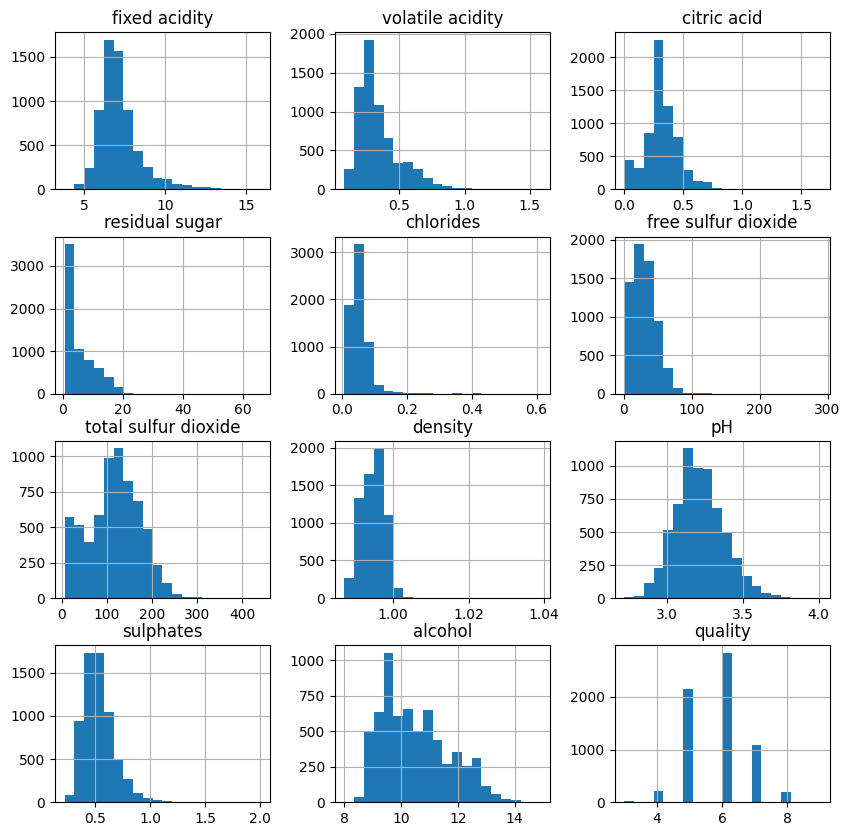

In [8]:
df.hist(bins=20,figsize=(10,10))
plt.show()

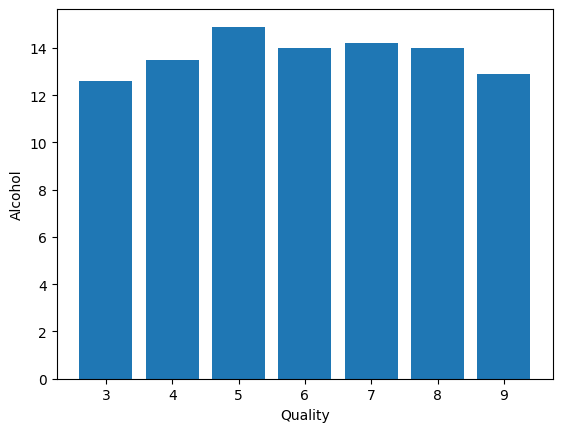

In [9]:
plt.bar(df['quality'],df['alcohol'])
plt.xlabel('Quality')
plt.ylabel('Alcohol')
plt.show()

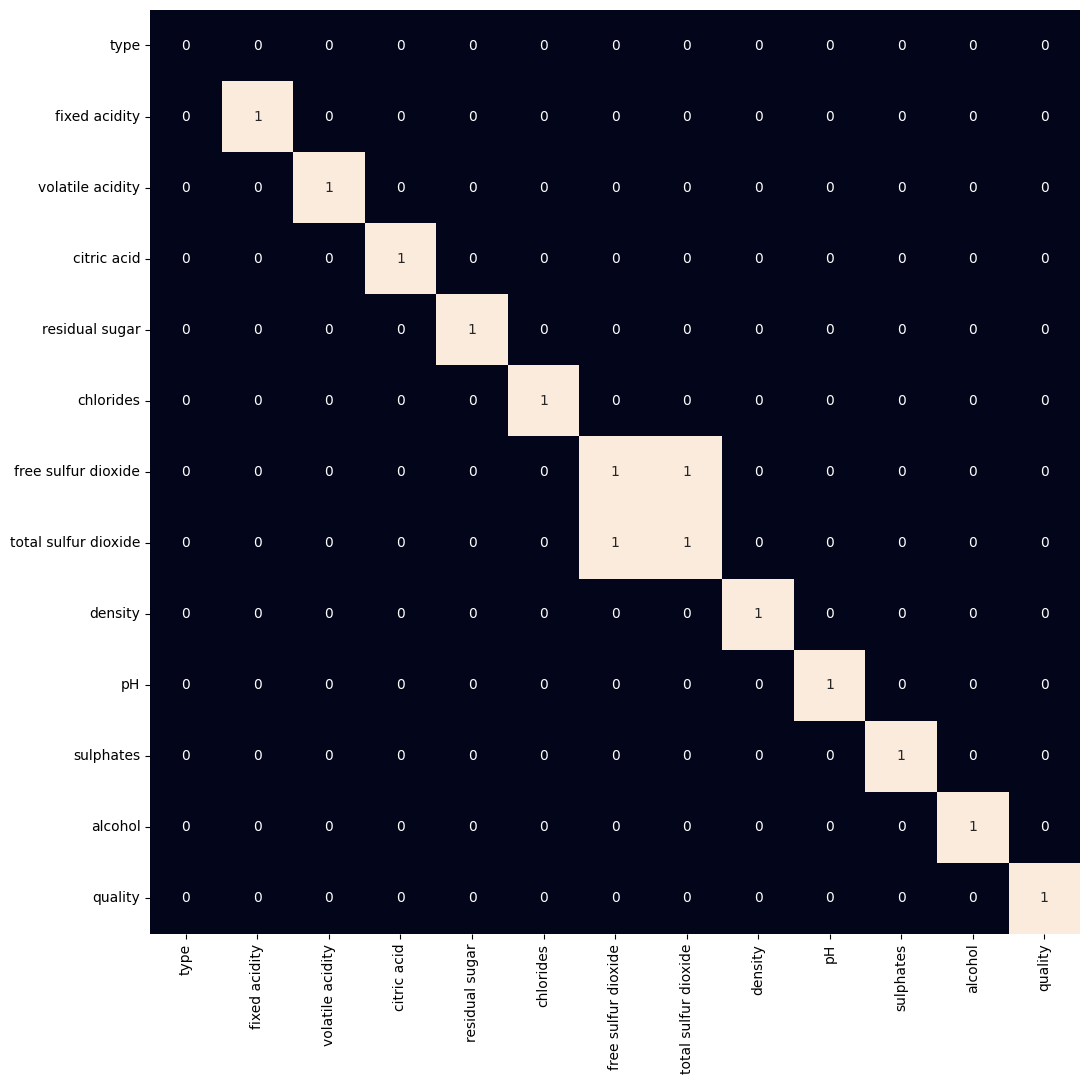

In [10]:
for col in df.columns:
  if df[col].dtype == 'object':
    try:
      df[col] = pd.to_numeric(df[col], errors='coerce')
    except Exception as e:
      print(f"Could not convert column {col} to numeric: {e}")
      pass

plt.figure(figsize=(12,12))
sns.heatmap(df.corr()>0.7,annot=True,cbar=False)
plt.show()

In [11]:
df = df.drop('total sulfur dioxide',axis = 1)

In [12]:
df ['Best Quality'] = [1 if x > 5 else 0 for x in df['quality']]


In [13]:
df.replace ({'white':1, 'red':0},inplace=True)

In [14]:
features = df.drop(['quality', 'Best Quality'], axis=1)
target = df['Best Quality']

xtrain, xtest, ytrain, ytest = train_test_split(
	features, target, test_size=0.2, random_state=42)


from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy='mean')
xtrain = imputer.fit_transform(xtrain)
xtest = imputer.transform(xtest)

xtrain.shape, xtest.shape

((5197, 10), (1300, 10))

In [15]:
norm = MinMaxScaler()
xtrain = norm.fit_transform(xtrain)
xtest = norm.transform(xtest)

In [17]:
models = [LogisticRegression(), XGBClassifier(), SVC(kernel='rbf')]

for i in range(3):
    models[i].fit(xtrain, ytrain)

    print(f'{models[i]} : ')
    print('Training Accuracy : ', metrics.roc_auc_score(ytrain, models[i].predict(xtrain)))
    print('Validation Accuracy : ', metrics.roc_auc_score(
        ytest, models[i].predict(xtest)))
    print()

LogisticRegression() : 
Training Accuracy :  0.6961377393342704
Validation Accuracy :  0.701255341880342

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...) : 
Training Accuracy :  0.9753322889617517
Validation Accuracy :  0.8250534188034188

SVC() : 
Training Accuracy :  0.721592308216027

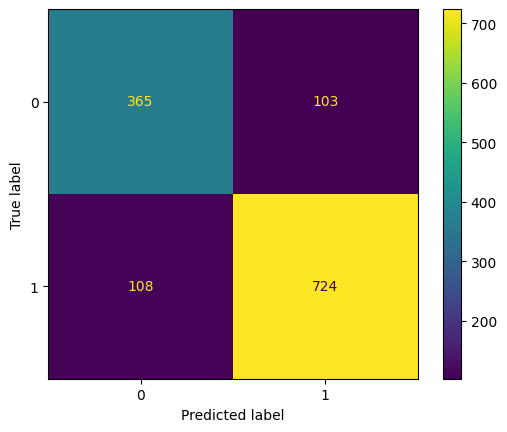

In [18]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(ytest, models[1].predict(xtest))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=models[1].classes_) # Assuming your model has a 'classes_' attribute
disp.plot()
plt.show()



In [19]:
print(metrics.classification_report(ytest,
                                    models[1].predict(xtest)))

              precision    recall  f1-score   support

           0       0.77      0.78      0.78       468
           1       0.88      0.87      0.87       832

    accuracy                           0.84      1300
   macro avg       0.82      0.83      0.82      1300
weighted avg       0.84      0.84      0.84      1300



In [20]:

best_model = models[1]


original_features_columns = df.drop(['quality', 'Best Quality', 'type'], axis=1).columns

sample_data = pd.DataFrame([[
    7.0,
    0.8,
    0.1,
    15.0,
    0.15,
    15.0,
    1.000,
    3.8,
    0.3,
    8.5
]], columns=original_features_columns)


scaled_sample = norm.transform(sample_data)


prediction = best_model.predict(scaled_sample)


predicted_quality = "not good quality (0)" if prediction[0] == 0 else "good quality (1)"
print(f"For the given wine characteristics, the model predicts: {predicted_quality}")

For the given wine characteristics, the model predicts: not good quality (0)


In [21]:
best_model = models[1]

original_features_columns = df.drop(['quality', 'Best Quality', 'type'], axis=1).columns

sample_data_good_quality = pd.DataFrame([[
    7.0,
    0.2,
    0.4,
    2.0,
    0.03,
    30.0,
    0.992,
    3.2,
    0.6,
    12.0
]], columns=original_features_columns)


scaled_sample_good_quality = norm.transform(sample_data_good_quality)


prediction_good_quality = best_model.predict(scaled_sample_good_quality)


predicted_quality_label = "not good quality (0)" if prediction_good_quality[0] == 0 else "good quality (1)"
print(f"For the given wine characteristics, the model predicts: {predicted_quality_label}")

For the given wine characteristics, the model predicts: good quality (1)
